In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [14]:
df = pd.read_csv("data/german_credit.csv")

df["target"] = df["default"].map({
    1: 0,
    2: 1
})

df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,age,installment_plan,housing,existing_credits,job,dependents,telephone,foreign_worker,default,target
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,67,none,own,2,skilled employee,1,yes,yes,1,0
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,22,none,own,1,skilled employee,1,none,yes,2,1
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,49,none,own,1,unskilled resident,2,none,yes,1,0
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,45,none,for free,1,skilled employee,2,none,yes,1,0
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,53,none,for free,2,skilled employee,2,none,yes,2,1


In [15]:
X = df.drop(
    columns=["default", "target"]
)

y = df["target"]

print(X.shape)
print(y.shape)

(1000, 20)
(1000,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 20)
(200, 20)


In [17]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['months_loan_duration', 'amount', 'installment_rate', 'residence_history', 'age', 'existing_credits', 'dependents']

Categorical Features:
['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_length', 'personal_status', 'other_debtors', 'property', 'installment_plan', 'housing', 'job', 'telephone', 'foreign_worker']


In [18]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [20]:
model.fit(
    X_train,
    y_train
)

print("Training completed.")

Training completed.


d:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [22]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.78
Precision: 0.6538461538461539
Recall   : 0.5666666666666667
F1 Score : 0.6071428571428571


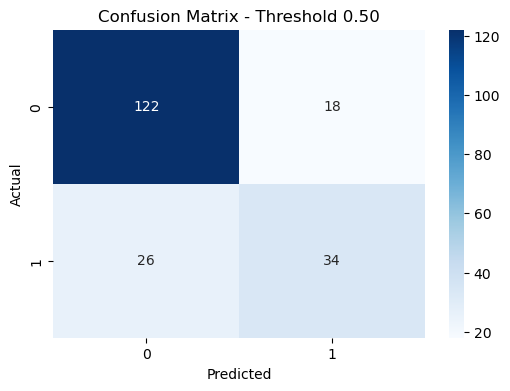

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Threshold 0.50")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
y_prob = model.predict_proba(X_test)[:, 1]

y_prob[:10]

array([0.23717163, 0.098476  , 0.60035722, 0.54256191, 0.15269745,
       0.1145529 , 0.22133536, 0.14098661, 0.50847836, 0.15194011])

In [25]:
threshold = 0.40

y_pred_40 = (
    y_prob >= threshold
).astype(int)

y_pred_40[:10]

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [26]:
acc_40 = accuracy_score(
    y_test,
    y_pred_40
)

prec_40 = precision_score(
    y_test,
    y_pred_40
)

rec_40 = recall_score(
    y_test,
    y_pred_40
)

f1_40 = f1_score(
    y_test,
    y_pred_40
)

print("Accuracy :", acc_40)
print("Precision:", prec_40)
print("Recall   :", rec_40)
print("F1 Score :", f1_40)

Accuracy : 0.785
Precision: 0.6268656716417911
Recall   : 0.7
F1 Score : 0.6614173228346457


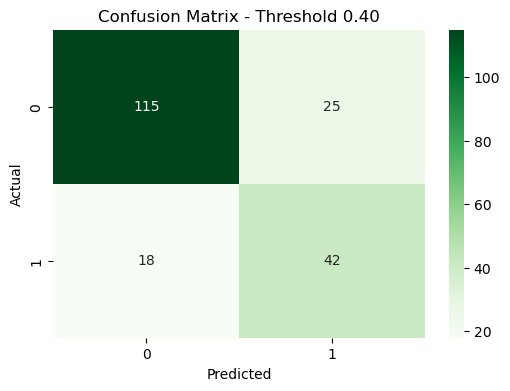

In [27]:
cm_40 = confusion_matrix(
    y_test,
    y_pred_40
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_40,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Threshold 0.40")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Threshold 0.50": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Threshold 0.40": [
        acc_40,
        prec_40,
        rec_40,
        f1_40
    ]
})

results

,Metric,Threshold 0.50,Threshold 0.40
0,Accuracy,0.780000,0.785000
1,Precision,0.653846,0.626866
2,Recall,0.566667,0.700000
3,F1 Score,0.607143,0.661417


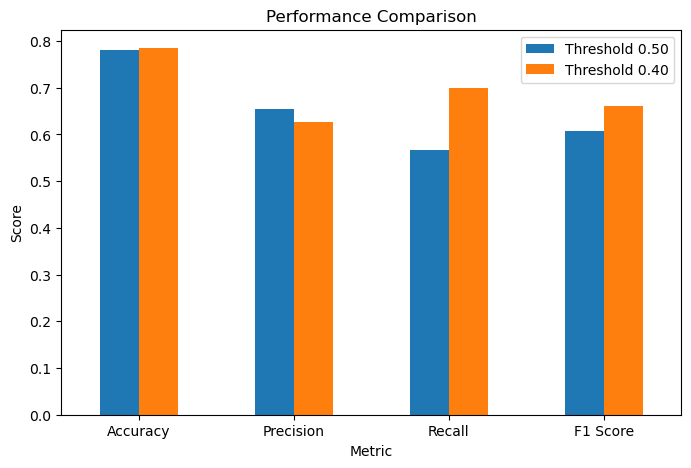

In [29]:
results_plot = results.set_index(
    "Metric"
)

results_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Performance Comparison"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=0
)

plt.show()

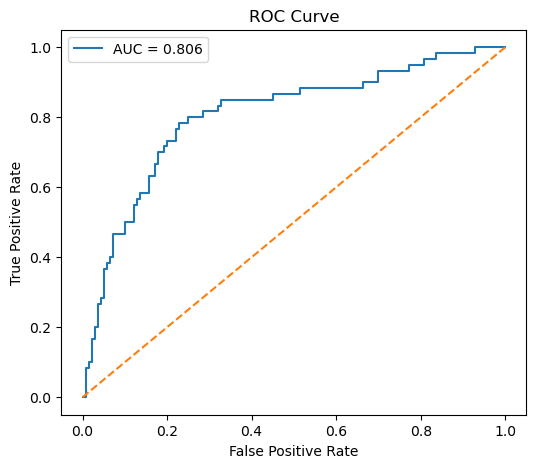

In [30]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

In [31]:
print(
    f"ROC-AUC Score: {roc_auc:.3f}"
)

ROC-AUC Score: 0.806


In [32]:
print("""
Business Conclusion

- Logistic Regression achieved solid baseline performance.
- Lowering the threshold from 0.50 to 0.40 improved recall significantly.
- Recall increased from 56.7% to 70.0%.
- This means fewer high-risk customers would be mistakenly approved.
- In credit risk assessment, improving recall is often more important than maximizing accuracy.
""")


Business Conclusion

- Logistic Regression achieved solid baseline performance.
- Lowering the threshold from 0.50 to 0.40 improved recall significantly.
- Recall increased from 56.7% to 70.0%.
- This means fewer high-risk customers would be mistakenly approved.
- In credit risk assessment, improving recall is often more important than maximizing accuracy.

